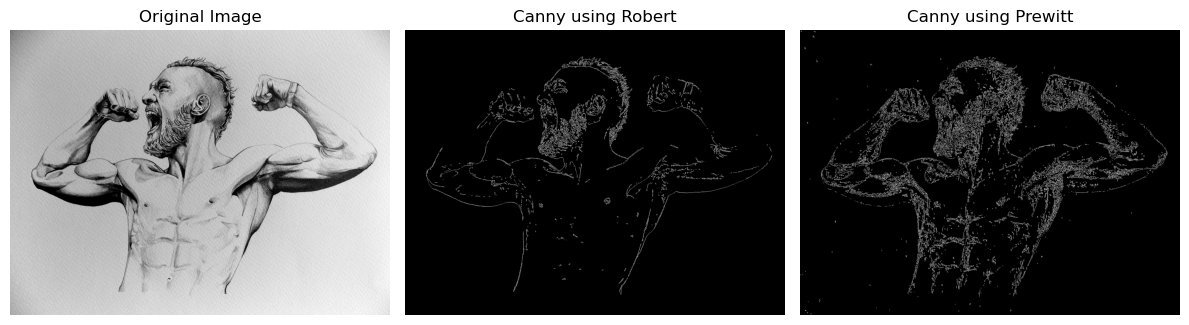

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('mc.png', cv2.IMREAD_GRAYSCALE)

def show_img(images, titles):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(12, 6))
    for i, axx in enumerate(ax):
        axx.imshow(images[i], cmap='gray')
        axx.set_title(titles[i])
        axx.axis("off")
    plt.tight_layout()
    plt.show()

def robert_filter(img):
    rob_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    rob_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)    
    grad_x = cv2.filter2D(img, cv2.CV_64F, rob_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, rob_y)    
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return grad_x, grad_y, np.uint8(magnitude)

def prewitt_filter(img):
    pr_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    pr_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)    
    grad_x = cv2.filter2D(img, cv2.CV_64F, pr_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, pr_y)    
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return grad_x, grad_y, np.uint8(magnitude)
    
def gradient_magnitude_direction(grad_x, grad_y):
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    direction = np.arctan2(grad_y, grad_x)  # Gradient direction in radians
    return magnitude, direction

def non_maximum_suppression(magnitude, direction):
    M, N = magnitude.shape
    suppressed = np.zeros((M, N), dtype=np.uint8)
    angle = np.rad2deg(direction) % 180    
    for i in range(1, M - 1):
        for j in range(1, N - 1):
            q, r = 255, 255  # Pixel values for comparison
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q, r = magnitude[i, j - 1], magnitude[i, j + 1]
            elif (22.5 <= angle[i, j] < 67.5):
                q, r = magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]
            elif (67.5 <= angle[i, j] < 112.5):
                q, r = magnitude[i - 1, j], magnitude[i + 1, j]
            elif (112.5 <= angle[i, j] < 157.5):
                q, r = magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]            
            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                suppressed[i, j] = magnitude[i, j]
            else:
                suppressed[i, j] = 0    
    return suppressed

def double_threshold_hysteresis(img, low_thresh, high_thresh):
    strong, weak = 255, 75
    M, N = img.shape
    result = np.zeros((M, N), dtype=np.uint8)
    strong_x, strong_y = np.where(img >= high_thresh)
    weak_x, weak_y = np.where((img >= low_thresh) & (img < high_thresh))
    result[strong_x, strong_y] = strong
    result[weak_x, weak_y] = weak
    for i in range(1, M - 1):
        for j in range(1, N - 1):
            if result[i, j] == weak:
                if (result[i + 1, j - 1:j + 2] == strong).any() or \
                   (result[i - 1, j - 1:j + 2] == strong).any() or \
                   (result[i, [j - 1, j + 1]] == strong).any():
                    result[i, j] = strong
                else:
                    result[i, j] = 0
    return result

grad_x_r, grad_y_r, mag_r = robert_filter(img)
mag_r, dir_r = gradient_magnitude_direction(grad_x_r, grad_y_r)
nms_r = non_maximum_suppression(mag_r, dir_r)
final_edges_r = double_threshold_hysteresis(nms_r, 30, 90)

grad_x_p, grad_y_p, mag_p = prewitt_filter(img)
mag_p, dir_p = gradient_magnitude_direction(grad_x_p, grad_y_p)
nms_p = non_maximum_suppression(mag_p, dir_p)
final_edges_p = double_threshold_hysteresis(nms_p, 30, 90)

show_img([img, final_edges_r, final_edges_p], ["Original Image", "Canny using Robert", "Canny using Prewitt"])